# Preference Debrief — Final Forced-comparison of the Three Forms

This notebook covers the **final preference debrief** — a single questionnaire asked
*once* at the very end of the session, after all three blocks, asking the
participant to compare the forms directly
(`OpenMATB/includes/questionnaires/study/preference_debrief.txt`).

Where H1–H4 each probe one block at a time, the debrief is a **direct
head-to-head**: with all three styles fresh in memory the participant picks which
block's automation messages were best on five dimensions. It is a convergent,
subjective cross-check on the per-block measures — especially H1 (which felt most
*informative*) and the H2–H4 mechanism (which felt most *useful* / *least
distracting*).

## The five debrief items

Each item is a single `genericscales` slider anchored by **block position**:
**left = 1st block · middle = 2nd block · right = 3rd block** (declared `1/7/4`,
i.e. 1 = 1st, 7 = 3rd, neutral default 4 = 2nd):

| Key | Question | Expected winner |
|-----|----------|-----------------|
| `PREF_q1_most_informative` | Which block's messages felt most **informative**? | **F1** (verbose) — the H1 prediction |
| `PREF_q2_most_useful` | Which block's messages **helped most when deciding** what to do? | **F2/F3** (contrastive / actionable) |
| `PREF_q3_most_trusted` | Which block's messages made you **trust** the automation most? | exploratory |
| `PREF_q4_least_distracting` | Which block's messages were **least distracting**? | **F2/F3** (shorter to read) |
| `PREF_q5_self_chosen` | Which style would you **choose** for a future task? | exploratory |

## From slider position to form

The slider records a *block position* (1st/2nd/3rd), not a form. Because the form
order is **counterbalanced per participant** (Latin square), the same position
means a different form for different participants. We therefore translate each
vote back to its form using the participant's known order
(`matb_analysis.study_design.PARTICIPANT_ORDERS`): the slider value is rounded to
the nearest of the three anchors (1 → 1st, 4 → 2nd, 7 → 3rd) and looked up against
that participant's form sequence. A slider left untouched sits at the neutral
default (4 → 2nd block); such rows are flagged so they are not read as a genuine
middle-block preference.

We report **descriptive vote tallies and visualisations**.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from matb_analysis.aggregate import build_debrief_table
from matb_analysis.discovery import find_study_sessions, DEFAULT_SESSIONS_DIR
from matb_analysis.study_design import PARTICIPANT_ORDERS

sns.set_theme(style="whitegrid")
FORM_ORDER = ["F1", "F2", "F3"]
FORM_LABELS = {"F1": "F1 verbose", "F2": "F2 contrastive", "F3": "F3 +actionable"}
FORM_COLORS = {"F1": "#3b6e8f", "F2": "#2e8b57", "F3": "#b8412e"}
OUT = Path.cwd().parent / "outputs"
OUT.mkdir(exist_ok=True)

PREF_ITEMS = {
    "PREF_q1_most_informative": "most informative",
    "PREF_q2_most_useful": "most useful for deciding",
    "PREF_q3_most_trusted": "most trusted",
    "PREF_q4_least_distracting": "least distracting",
    "PREF_q5_self_chosen": "would choose again",
}

# Read the curated study sessions from session_logs/. Whichever candidate
# directory actually contains study sessions is used, so this runs unchanged
# as real participants are collected.
CANDIDATES = [Path.cwd().parent / "session_logs", DEFAULT_SESSIONS_DIR]
DATA_DIR = next((d for d in CANDIDATES if find_study_sessions(d)), CANDIDATES[0])

## 1. Load the debrief responses

`build_debrief_table()` returns one row per *session that reached the debrief*,
with the five preference sliders on their raw 1–7 (block-position) scale. Only
completed sessions contribute, so this table may be smaller than the per-block
metrics table.

In [2]:
sessions = find_study_sessions(DATA_DIR)
print(f"Reading logs from: {DATA_DIR}")
print(f"Discovered {len(sessions)} study session(s).")

debrief = build_debrief_table(sessions)
print(f"{len(debrief)} session(s) reached the debrief.")
debrief

Reading logs from: c:\Projects\HumanCenteredAI\Analysis\session_logs
Discovered 12 study session(s).
12 session(s) reached the debrief.


,participant,session_file,PREF_q1_most_informative,PREF_q2_most_useful,PREF_q3_most_trusted,PREF_q4_least_distracting,PREF_q5_self_chosen
0,P16,12_260707_083340.csv,6.505787,6.324942,6.527488,6.324942,6.570891
1,P17,13_260707_090707.csv,6.621528,6.650463,5.890914,6.664931,6.780671
2,P10,14_260706_094057.csv,7.000000,7.000000,7.000000,1.000000,7.000000
3,P02,2_260626_210403.csv,1.000000,4.000000,4.000000,7.000000,4.000000
4,P01,32_260628_201452.csv,1.000000,7.000000,7.000000,7.000000,7.000000
5,P03,3_260627_201956.csv,7.000000,7.000000,4.000000,7.000000,7.000000
6,P04,5_260627_210129.csv,7.000000,4.000000,4.000000,1.000000,4.000000
7,P05,6_260630_191212.csv,1.000000,1.000000,1.000000,1.000000,1.000000
8,P06,7_260701_205132.csv,1.000000,1.000000,1.000000,1.000000,1.000000
9,P08,7_260706_000835.csv,7.000000,1.000000,6.122396,4.000000,5.420718


## 2. Translate each slider vote into a form

The helper below maps a raw slider value to a block position (1 → 1st, 4 → 2nd,
7 → 3rd, by nearest anchor) and then to the form that participant saw in that
position. The result is a tidy long table: one row per (participant, question)
with the **chosen form** and a `was_neutral` flag for sliders left at the default.

In [3]:
ANCHORS = {1.0: 0, 4.0: 1, 7.0: 2}  # slider value -> block position index (0/1/2)
POS_VALUES = np.array([1.0, 4.0, 7.0])

def value_to_position(value: float) -> int:
    """Nearest block position (0=1st, 1=2nd, 2=3rd) for a 1..7 slider value."""
    return int(np.argmin(np.abs(POS_VALUES - float(value))))

def form_for_participant_position(participant: str, pos: int) -> str | float:
    order = PARTICIPANT_ORDERS.get(participant)
    if order is None or pos >= len(order):
        return float("nan")
    return order[pos][0]  # (form, block) -> form

records = []
for _, row in debrief.iterrows():
    for key, label in PREF_ITEMS.items():
        val = row[key]
        if pd.isna(val):
            continue
        pos = value_to_position(val)
        records.append({
            "participant": row["participant"],
            "question": key,
            "label": label,
            "slider_value": val,
            "block_position": pos + 1,
            "chosen_form": form_for_participant_position(row["participant"], pos),
            "was_neutral": bool(abs(val - 4.0) < 1e-9),
        })

votes = pd.DataFrame(records)
votes

,participant,question,label,slider_value,block_position,chosen_form,was_neutral
0,P16,PREF_q1_most_informative,most informative,6.505787,3,F1,False
1,P16,PREF_q2_most_useful,most useful for deciding,6.324942,3,F1,False
2,P16,PREF_q3_most_trusted,most trusted,6.527488,3,F1,False
3,P16,PREF_q4_least_distracting,least distracting,6.324942,3,F1,False
4,P16,PREF_q5_self_chosen,would choose again,6.570891,3,F1,False
5,P17,PREF_q1_most_informative,most informative,6.621528,3,F3,False
6,P17,PREF_q2_most_useful,most useful for deciding,6.650463,3,F3,False
7,P17,PREF_q3_most_trusted,most trusted,5.890914,3,F3,False
8,P17,PREF_q4_least_distracting,least distracting,6.664931,3,F3,False
9,P17,PREF_q5_self_chosen,would choose again,6.780671,3,F3,False


## 3. Vote tallies per question

For each debrief item, how many participants picked each form. With the form order
counterbalanced, a form winning a question means it won *on its merits*, not
because of where it happened to fall in the session. The `n_neutral` column counts
untouched (default = 2nd-block) sliders for transparency.

In [4]:
tally = (votes.pivot_table(index="question", columns="chosen_form",
                           values="participant", aggfunc="count", fill_value=0)
              .reindex(columns=FORM_ORDER, fill_value=0)
              .reindex(list(PREF_ITEMS.keys())))
tally["n_neutral"] = (votes[votes["was_neutral"]]
                      .groupby("question").size()
                      .reindex(list(PREF_ITEMS.keys()), fill_value=0))
tally["n_total"] = tally[FORM_ORDER].sum(axis=1)
tally

chosen_form,F1,F2,F3,n_neutral,n_total
question,,,,,
PREF_q1_most_informative,6,0,6,0,12
PREF_q2_most_useful,2,2,8,3,12
PREF_q3_most_trusted,4,1,7,3,12
PREF_q4_least_distracting,3,2,7,1,12
PREF_q5_self_chosen,1,2,9,3,12


**Figure 1 — debrief votes per question, by form.** Stacked bars; each segment is
the share of participants who picked that form for that question. The study
predicts **F1** to win *most informative* (the H1 feeling), while **F2/F3** win
*most useful* and *least distracting* (the H2–H4 mechanism).

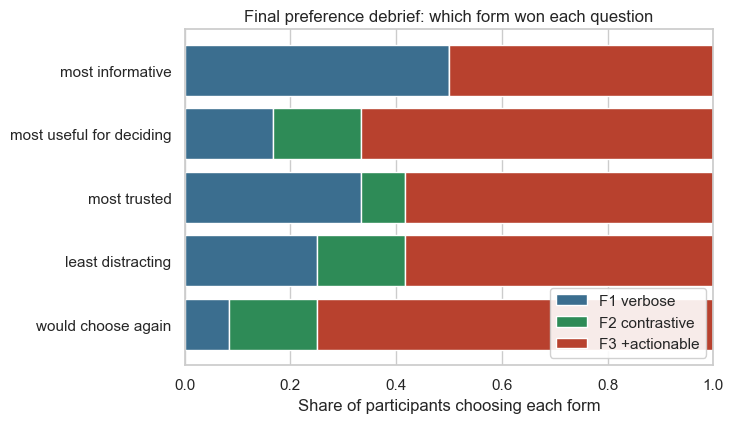

In [5]:
shares = tally[FORM_ORDER].div(tally["n_total"].replace(0, np.nan), axis=0).fillna(0)
labels = [PREF_ITEMS[q] for q in shares.index]
y = np.arange(len(shares))

fig, ax = plt.subplots(figsize=(7.5, 4.4))
left = np.zeros(len(shares))
for form in FORM_ORDER:
    ax.barh(y, shares[form].values, left=left, color=FORM_COLORS[form],
            label=FORM_LABELS[form], edgecolor="white")
    left += shares[form].values
ax.set_yticks(y)
ax.set_yticklabels(labels)
ax.invert_yaxis()
ax.set_xlim(0, 1)
ax.set_xlabel("Share of participants choosing each form")
ax.set_title("Final preference debrief: which form won each question")
ax.legend(loc="lower right", framealpha=0.9)
fig.tight_layout()
fig.savefig(OUT / "preference_debrief_votes.png", dpi=150)
plt.show()

## 4. The H1-relevant item — "most informative"

`PREF_q1_most_informative` is the debrief's direct echo of **H1**: with all three
styles fresh, which one *felt* the most informative? H1 predicts a **verbose (F1)**
majority here — and, read against `PREF_q4_least_distracting` (predicted F2/F3),
the same dissociation the H1↔H2 pair makes per block: the form that feels most
informative is not the one that is easiest to act on.

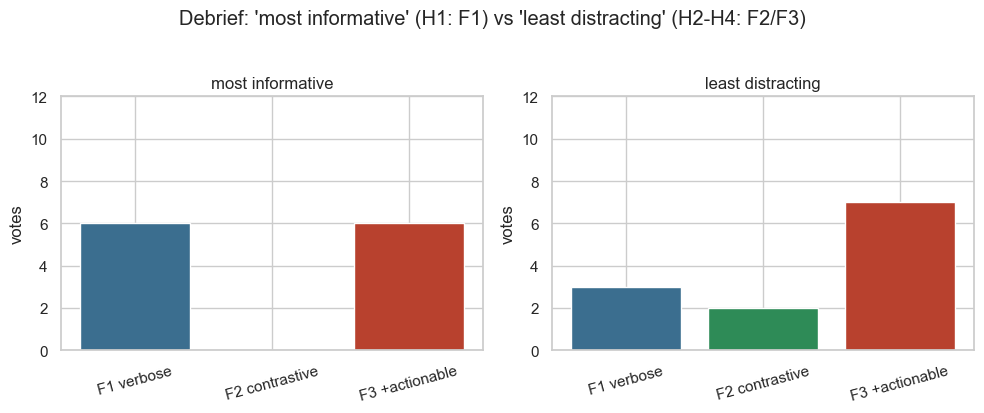

In [6]:
focus = ["PREF_q1_most_informative", "PREF_q4_least_distracting"]
fig, axes = plt.subplots(1, 2, figsize=(10, 4.0))
for ax, q in zip(axes, focus):
    counts = tally.loc[q, FORM_ORDER]
    ax.bar([FORM_LABELS[f] for f in FORM_ORDER], counts.values,
           color=[FORM_COLORS[f] for f in FORM_ORDER])
    ax.set_ylabel("votes")
    ax.set_title(PREF_ITEMS[q])
    ax.set_ylim(0, max(1, tally.loc[q, "n_total"]))
    ax.tick_params(axis="x", labelrotation=15)
fig.suptitle("Debrief: 'most informative' (H1: F1) vs 'least distracting' (H2-H4: F2/F3)", y=1.03)
fig.tight_layout()
fig.savefig(OUT / "preference_debrief_informative_vs_distracting.png", dpi=150)
plt.show()

## 5. Compact summary table

One row per question with each form's vote share, suitable for the report.

In [7]:
summary = shares.copy()
summary.index = [PREF_ITEMS[q] for q in summary.index]
summary["n_total"] = tally["n_total"].values
summary = summary.round(3)
summary.to_csv(OUT / "preference_debrief_summary.csv")
summary

chosen_form,F1,F2,F3,n_total
most informative,0.500,0.000,0.500,12
most useful for deciding,0.167,0.167,0.667,12
most trusted,0.333,0.083,0.583,12
least distracting,0.250,0.167,0.583,12
would choose again,0.083,0.167,0.750,12
